# Blunder prediction from Lichess engine-eval data

This notebook builds a first supervised ML task for the final project:

> Given the current state of a game, predict whether the player to move will
> make a blunder within their next few moves.

This version is designed for fast iteration. The number of games is controlled
near the top with `N_GAMES_SAMPLE`.

Drop this notebook into:

```text
scratch/blunder_prediction_02_sampled.ipynb
```

It expects processed data at:

```text
data/processed/lichess-2017-05-eval-all/
```


## 0. Main controls

Change these values first.

For early debugging, use:

```python
N_GAMES_SAMPLE = 5_000
```

For a more realistic baseline, use:

```python
N_GAMES_SAMPLE = 50_000
```

For the full dataset, set:

```python
N_GAMES_SAMPLE = None
```


In [21]:
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.compose import ColumnTransformer
from sklearn.dummy import DummyClassifier
from sklearn.ensemble import HistGradientBoostingClassifier
from sklearn.impute import SimpleImputer
from sklearn.inspection import permutation_importance
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import (
  ConfusionMatrixDisplay,
  PrecisionRecallDisplay,
  RocCurveDisplay,
  average_precision_score,
  balanced_accuracy_score,
  classification_report,
  confusion_matrix,
  f1_score,
  roc_auc_score,
)
from sklearn.model_selection import GroupShuffleSplit
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import OneHotEncoder, StandardScaler

RANDOM_STATE = 42

# Main runtime control. Set to None to use all games.
N_GAMES_SAMPLE = 50_000

# If True, sample random games. If False, take the first N games.
RANDOM_GAME_SAMPLE = True

# Blunder definition and prediction horizon.
BLUNDER_CP = 100
MISTAKE_CP = 100
HORIZON_OWN_MOVES = 5

# Mate / extreme evals can dominate simple cp-based features.
MAX_ABS_CP = 5000

pd.set_option("display.max_columns", 120)


## 1. Locate the project root and load the data

This block should work whether you launch Jupyter from the project root or from
`scratch/`.


In [22]:
def find_project_root(start=None):
  if start is None:
    start = Path.cwd()

  start = Path(start).resolve()

  for path in [start, *start.parents]:
    has_pyproject = (path / "pyproject.toml").exists()
    has_data = (path / "data").exists()

    if has_pyproject and has_data:
      return path

  raise FileNotFoundError(
    "Could not find project root. Run from the project root "
    "or from a subdirectory such as scratch/."
  )


ROOT = find_project_root()
DATA_DIR = ROOT / "data" / "processed" / "lichess-2017-05-eval-all"

GAMES_PATH = DATA_DIR / "games.parquet"
PLIES_PATH = DATA_DIR / "plies.parquet"
FEATURES_PATH = DATA_DIR / "features.parquet"
DICT_PATH = DATA_DIR / "feature_dictionary.csv"

print(f"Project root: {ROOT}")
print(f"Data dir:     {DATA_DIR}")

for path in [GAMES_PATH, PLIES_PATH, FEATURES_PATH, DICT_PATH]:
  print(f"{path.name:24s} exists={path.exists()}")


Project root: /Users/asudler/Desktop/ucph/coursework/2526-block4/aml/final-project/root/workspace/aidan_sandbox/blunder
Data dir:     /Users/asudler/Desktop/ucph/coursework/2526-block4/aml/final-project/root/workspace/aidan_sandbox/blunder/data/processed/lichess-2017-05-eval-all
games.parquet            exists=True
plies.parquet            exists=True
features.parquet         exists=True
feature_dictionary.csv   exists=True


In [23]:
games = pd.read_parquet(GAMES_PATH)
plies = pd.read_parquet(PLIES_PATH)
features = pd.read_parquet(FEATURES_PATH)

if DICT_PATH.exists():
  feature_dict = pd.read_csv(DICT_PATH)
else:
  feature_dict = pd.DataFrame()

print("games:", games.shape)
print("plies:", plies.shape)
print("features:", features.shape)
print("feature_dict:", feature_dict.shape)


games: (957369, 17)
plies: (61361243, 39)
features: (957369, 80)
feature_dict: (6, 5)


## 2. Quick schema inspection and column detection

The notebook tries to infer likely column names. If it guesses wrong, fill in
`COLUMN_OVERRIDES`.


In [24]:
print("games columns")
display(pd.DataFrame({"column": games.columns}))

print("plies columns")
display(pd.DataFrame({"column": plies.columns}))

print("features columns")
display(pd.DataFrame({"column": features.columns}))


games columns


,column
0,game_index
1,event
2,site
3,white
4,black
5,result
6,result_white
7,white_elo
8,black_elo
9,avg_elo


plies columns


,column
0,game_index
1,ply
2,move_number
3,side
4,san_raw
5,comment_raw
6,eval_raw
7,eval_pawns
8,is_mate_eval
9,mate_distance


features columns


,column
0,game_index
1,n_plies
2,n_eval_available
3,frac_eval_available
4,n_missing_eval
...,...
75,opening
76,time_control
77,time_base_seconds
78,time_increment_seconds


In [25]:
if len(feature_dict) > 0:
  display(feature_dict.head(50))


,table,column,meaning,raw_or_derived,unit
0,plies,eval_pawns,Engine eval from White's perspective in pawn u...,raw-parsed,pawns
1,plies,eval_proxy,Finite mate-aware numeric eval used for summar...,derived,pawns proxy
2,plies,phase_progress,Fraction of starting non-pawn material removed.,derived,unitless
3,features,mean_abs_eval_change,Mean absolute change in eval_proxy per ply.,derived,pawns proxy
4,features,white_mean_loss_proxy,Mean eval loss after White moves.,derived,pawns proxy
5,features,black_mean_loss_proxy,Mean eval loss after Black moves.,derived,pawns proxy


In [26]:
COLUMN_OVERRIDES = {
  # Fill these in only if auto-detection guesses wrong.
  #
  # Examples:
  # "game_id": "game_id",
  # "ply_index": "ply_index",
  # "eval_cp": "eval_cp",
  # "turn": "turn",
}


In [27]:
def pick_column(df, candidates, required=True, role="column"):
  for key in candidates:
    if key in COLUMN_OVERRIDES:
      override = COLUMN_OVERRIDES[key]
      if override in df.columns:
        return override

  for name in candidates:
    if name in df.columns:
      return name

  if required:
    cols = ", ".join(candidates)
    raise KeyError(f"Could not find {role}. Tried: {cols}")

  return None


def pick_contains(df, include, exclude=None, required=True, role="column"):
  if exclude is None:
    exclude = []

  include = [x.lower() for x in include]
  exclude = [x.lower() for x in exclude]

  matches = []
  for col in df.columns:
    low = col.lower()
    has_all = all(x in low for x in include)
    has_excl = any(x in low for x in exclude)
    if has_all and not has_excl:
      matches.append(col)

  if matches:
    return matches[0]

  if required:
    raise KeyError(f"Could not find {role} containing {include}")

  return None


game_id_col = pick_column(
  plies,
  ["game_id", "game_index", "game_idx", "id"],
  role="game id column",
)

ply_col = pick_column(
  plies,
  ["ply", "ply_index", "ply_number", "move_ply"],
  role="ply index column",
)

eval_col = pick_column(
  plies,
  [
    "eval_cp",
    "cp",
    "centipawn",
    "stockfish_eval_cp",
    "engine_eval_cp",
  ],
  required=False,
  role="engine eval cp column",
)

if eval_col is None:
  eval_col = pick_contains(
    plies,
    ["eval"],
    exclude=["mate", "raw", "comment"],
    role="engine eval cp column",
  )

turn_col = pick_column(
  plies,
  ["turn", "side", "color", "player_color"],
  required=False,
  role="side-to-move column",
)

print("Detected columns")
print("game_id_col:", game_id_col)
print("ply_col:    ", ply_col)
print("eval_col:   ", eval_col)
print("turn_col:   ", turn_col)


Detected columns
game_id_col: game_index
ply_col:     ply
eval_col:    eval_pawns
turn_col:    side


## 3. Sample games early

This is the key difference from the first notebook.

We sample games before creating labels and features, so all later operations are
fast. Sampling by game preserves complete games rather than taking arbitrary
rows.


In [28]:
def sample_games(df, n_games, random_sample=True, seed=RANDOM_STATE):
  if n_games is None:
    return df.copy()

  game_ids = df[game_id_col].drop_duplicates()

  if n_games >= len(game_ids):
    return df.copy()

  if random_sample:
    selected_ids = game_ids.sample(n_games, random_state=seed)
  else:
    selected_ids = game_ids.head(n_games)

  sampled = df[df[game_id_col].isin(selected_ids)].copy()
  sampled = sampled.sort_values([game_id_col, ply_col]).reset_index(drop=True)

  return sampled


plies = sample_games(
  plies,
  N_GAMES_SAMPLE,
  random_sample=RANDOM_GAME_SAMPLE,
)

sampled_game_ids = set(plies[game_id_col].drop_duplicates())

if game_id_col in games.columns:
  games = games[games[game_id_col].isin(sampled_game_ids)].copy()

if game_id_col in features.columns:
  features = features[features[game_id_col].isin(sampled_game_ids)].copy()

print("After sampling")
print("games:", games.shape)
print("plies:", plies.shape)
print("features:", features.shape)
print("unique games in plies:", plies[game_id_col].nunique())


After sampling
games: (50000, 17)
plies: (3198759, 39)
features: (50000, 80)
unique games in plies: 50000


## 4. Define move-level blunders

Convention:

- Engine eval is assumed to be from White's perspective.
- Positive eval means White is better.
- Negative eval means Black is better.

For the player who just moved:

- If White moved, a bad move causes `eval_after - eval_before` to decrease.
- If Black moved, a bad move causes `eval_after - eval_before` to increase.


In [41]:
def normalize_turn_value(x):
  if pd.isna(x):
    return np.nan

  value = str(x).strip().lower()

  if value in {"w", "white", "1", "true"}:
    return "white"

  if value in {"b", "black", "0", "false"}:
    return "black"

  return value


def add_basic_ply_columns(df):
  df = df.copy()
  df = df.sort_values([game_id_col, ply_col]).reset_index(drop=True)

  df["eval_cp"] = pd.to_numeric(df[eval_col], errors="coerce")
  df["eval_cp"] = df["eval_cp"].clip(-MAX_ABS_CP, MAX_ABS_CP)

  if turn_col is not None:
    df["side_to_move"] = df[turn_col].map(normalize_turn_value)
  else:
    df["side_to_move"] = np.where(df[ply_col] % 2 == 1, "white", "black")

  df["mover"] = df["side_to_move"]
  df["ply_number"] = pd.to_numeric(df[ply_col], errors="coerce")
  df["fullmove_number"] = ((df["ply_number"] + 1) // 2).astype("Int64")

  return df


def add_blunder_labels(df):
  df = df.copy()
  group = df.groupby(game_id_col, sort=False)

  df["eval_after_cp"] = group["eval_cp"].shift(-1)
  df["eval_delta_cp"] = df["eval_after_cp"] - df["eval_cp"]

  white_loss = -df["eval_delta_cp"]
  black_loss = df["eval_delta_cp"]

  df["cp_loss"] = np.where(
    df["mover"].eq("white"),
    white_loss,
    black_loss,
  )

  df["cp_loss"] = df["cp_loss"].clip(lower=0)
  df["is_mistake"] = df["cp_loss"].ge(MISTAKE_CP).astype(int)
  df["is_blunder"] = df["cp_loss"].ge(BLUNDER_CP).astype(int)

  return df


plies_ml = add_basic_ply_columns(plies)
plies_ml = add_blunder_labels(plies_ml)

print("Eval summary")
display(plies_ml["eval_cp"].describe(percentiles=[
  0.01,
  0.05,
  0.25,
  0.5,
  0.75,
  0.95,
  0.99,
]))

print("Eval delta summary")
display(plies_ml["eval_delta_cp"].describe(percentiles=[
  0.01,
  0.05,
  0.25,
  0.5,
  0.75,
  0.95,
  0.99,
]))

print("CP loss summary")
display(plies_ml["cp_loss"].describe(percentiles=[
  0.5,
  0.75,
  0.9,
  0.95,
  0.99,
  0.999,
]))

print("Largest cp losses")
display(
  plies_ml[
    [game_id_col, ply_col, "mover", "eval_cp", "eval_after_cp", "cp_loss"]
  ]
  .sort_values("cp_loss", ascending=False)
  .head(20)
)

display(plies_ml[
  [
    game_id_col,
    ply_col,
    "mover",
    "eval_cp",
    "eval_after_cp",
    "eval_delta_cp",
    "cp_loss",
    "is_blunder",
  ]
].head(20))


Eval summary


count    2.934969e+06
mean     1.209009e-01
std      8.468654e+00
min     -1.285000e+02
1%      -1.901000e+01
5%      -8.140000e+00
25%     -9.000000e-01
50%      1.500000e-01
75%      1.140000e+00
95%      8.330000e+00
99%      1.927000e+01
max      1.285000e+02
Name: eval_cp, dtype: float64

Eval delta summary


count    2.860484e+06
mean    -2.639763e-05
std      4.856106e+00
min     -1.809800e+02
1%      -8.150000e+00
5%      -2.200000e+00
25%     -2.100000e-01
50%      0.000000e+00
75%      2.000000e-01
95%      2.220000e+00
99%      8.230000e+00
max      1.309400e+02
Name: eval_delta_cp, dtype: float64

CP loss summary


count    2.860484e+06
mean     3.298089e-02
std      8.392313e-01
min     -0.000000e+00
50%      0.000000e+00
75%      0.000000e+00
90%      3.000000e-02
95%      8.000000e-02
99%      2.600000e-01
99.9%    3.180000e+00
max      1.041800e+02
Name: cp_loss, dtype: float64

Largest cp losses


,game_index,ply,mover,eval_cp,eval_after_cp,cp_loss
30688,109332,54,black,-121.45,-17.27,104.18
1150965,4089546,60,black,-128.50,-25.20,103.30
1489695,5323180,51,white,126.37,23.24,103.13
2903073,10563563,55,white,122.94,20.49,102.45
2263781,8197492,58,black,-128.49,-27.50,100.99
2568533,9331592,72,black,-124.79,-24.36,100.43
3047226,11127879,43,white,128.24,28.24,100.00
793491,2801316,39,white,114.65,14.70,99.95
2848564,10357237,61,white,122.64,23.20,99.44
2425334,8799314,56,black,-121.93,-22.63,99.30


,game_index,ply,mover,eval_cp,eval_after_cp,eval_delta_cp,cp_loss,is_blunder
0,246,1,white,0.10,0.14,0.04,0.00,0
1,246,2,black,0.14,0.13,-0.01,0.00,0
2,246,3,white,0.13,0.12,-0.01,0.01,0
3,246,4,black,0.12,0.06,-0.06,0.00,0
4,246,5,white,0.06,0.11,0.05,0.00,0
5,246,6,black,0.11,0.16,0.05,0.05,0
6,246,7,white,0.16,0.15,-0.01,0.01,0
7,246,8,black,0.15,0.14,-0.01,0.00,0
8,246,9,white,0.14,0.17,0.03,0.00,0
9,246,10,black,0.17,0.10,-0.07,0.00,0


,fraction
is_mistake,0.000002
is_blunder,0.000002


count    2.860484e+06
mean     3.298089e-02
std      8.392313e-01
min     -0.000000e+00
50%      0.000000e+00
75%      0.000000e+00
90%      3.000000e-02
95%      8.000000e-02
99%      2.600000e-01
max      1.041800e+02
Name: cp_loss, dtype: float64

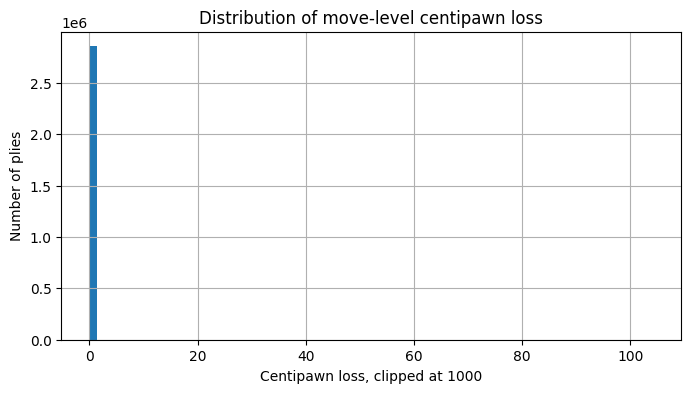

In [30]:
label_summary = plies_ml[["is_mistake", "is_blunder"]].mean()
display(label_summary.to_frame("fraction"))

display(plies_ml["cp_loss"].describe(percentiles=[
  0.5,
  0.75,
  0.9,
  0.95,
  0.99,
]))

fig, ax = plt.subplots(figsize=(8, 4))
plies_ml["cp_loss"].clip(0, 1000).hist(bins=80, ax=ax)
ax.set_xlabel("Centipawn loss, clipped at 1000")
ax.set_ylabel("Number of plies")
ax.set_title("Distribution of move-level centipawn loss")
plt.show()


## 5. Fast future-blunder target

This version avoids looping over every game.

It groups by `(game_id, mover)` and shifts within each player's own move
sequence.


In [31]:
def add_future_blunder_target_fast(df, horizon_own_moves):
  df = df.copy()
  df = df.sort_values([game_id_col, "mover", ply_col])

  keys = [game_id_col, "mover"]
  group = df.groupby(keys, sort=False)["is_blunder"]

  future_count = pd.Series(0, index=df.index, dtype=float)

  for step in range(1, horizon_own_moves + 1):
    future_count += group.shift(-step).fillna(0)

  df["future_blunder_count"] = future_count
  df["will_blunder_soon"] = (
    df["future_blunder_count"].gt(0).astype(int)
  )

  df = df.sort_values([game_id_col, ply_col]).reset_index(drop=True)

  return df


plies_ml = add_future_blunder_target_fast(
  plies_ml,
  HORIZON_OWN_MOVES,
)

target_rate = plies_ml["will_blunder_soon"].mean()
print(f"Target rate: {target_rate:.4f}")

display(plies_ml[
  [
    game_id_col,
    ply_col,
    "mover",
    "is_blunder",
    "future_blunder_count",
    "will_blunder_soon",
  ]
].head(30))


Target rate: 0.0000


,game_index,ply,mover,is_blunder,future_blunder_count,will_blunder_soon
0,246,1,white,0,0.0,0
1,246,2,black,0,0.0,0
2,246,3,white,0,0.0,0
3,246,4,black,0,0.0,0
4,246,5,white,0,0.0,0
5,246,6,black,0,0.0,0
6,246,7,white,0,0.0,0
7,246,8,black,0,0.0,0
8,246,9,white,0,0.0,0
9,246,10,black,0,0.0,0


## 6. Create legal pre-blunder features

These features use only information available up to the current position.

Leakage columns intentionally excluded:

- `eval_after_cp`
- `eval_delta_cp`
- `cp_loss`
- `is_mistake`
- `is_blunder`
- `future_blunder_count`
- `will_blunder_soon`


In [32]:
def add_rolling_features(df):
  df = df.copy()
  df = df.sort_values([game_id_col, ply_col]).reset_index(drop=True)

  group = df.groupby(game_id_col, sort=False)

  df["abs_eval_cp"] = df["eval_cp"].abs()
  df["eval_sign"] = np.sign(df["eval_cp"]).astype(float)

  df["eval_prev_1"] = group["eval_cp"].shift(1)
  df["eval_prev_2"] = group["eval_cp"].shift(2)
  df["eval_prev_4"] = group["eval_cp"].shift(4)

  df["eval_change_prev_1"] = df["eval_cp"] - df["eval_prev_1"]
  df["eval_change_prev_2"] = df["eval_cp"] - df["eval_prev_2"]
  df["eval_change_prev_4"] = df["eval_cp"] - df["eval_prev_4"]

  df["abs_eval_change_prev_1"] = df["eval_change_prev_1"].abs()
  df["abs_eval_change_prev_2"] = df["eval_change_prev_2"].abs()
  df["abs_eval_change_prev_4"] = df["eval_change_prev_4"].abs()

  df["game_ply_fraction"] = group.cumcount()
  max_ply = group["game_ply_fraction"].transform("max").replace(0, np.nan)
  df["game_ply_fraction"] = df["game_ply_fraction"] / max_ply

  df["phase"] = pd.cut(
    df["fullmove_number"].astype(float),
    bins=[0, 10, 25, 10_000],
    labels=["opening", "middlegame", "endgame"],
    include_lowest=True,
  )

  return df


def add_player_history_features(df):
  df = df.copy()
  df = df.sort_values([game_id_col, ply_col]).reset_index(drop=True)

  keys = [game_id_col, "mover"]
  group = df.groupby(keys, sort=False)

  prev_blunder = group["is_blunder"].shift(1).fillna(0)
  prev_mistake = group["is_mistake"].shift(1).fillna(0)
  prev_cp_loss = group["cp_loss"].shift(1)

  hist_keys = [df[game_id_col], df["mover"]]

  df["prev_own_blunders"] = (
    prev_blunder
    .groupby(hist_keys, sort=False)
    .cumsum()
  )

  df["prev_own_mistakes"] = (
    prev_mistake
    .groupby(hist_keys, sort=False)
    .cumsum()
  )

  df["prev_own_cp_loss"] = prev_cp_loss

  for window in [3, 5, 10]:
    shifted_loss = group["cp_loss"].shift(1)

    rolled = (
      shifted_loss
      .groupby(hist_keys, sort=False)
      .rolling(window, min_periods=1)
      .mean()
    )

    df[f"prev_own_cp_loss_mean_{window}"] = (
      rolled.reset_index(level=[0, 1], drop=True)
    )

  return df


plies_ml = add_rolling_features(plies_ml)
plies_ml = add_player_history_features(plies_ml)


In [33]:
candidate_features = [
  "eval_cp",
  "abs_eval_cp",
  "eval_sign",
  "fullmove_number",
  "game_ply_fraction",
  "eval_prev_1",
  "eval_prev_2",
  "eval_prev_4",
  "eval_change_prev_1",
  "eval_change_prev_2",
  "eval_change_prev_4",
  "abs_eval_change_prev_1",
  "abs_eval_change_prev_2",
  "abs_eval_change_prev_4",
  "prev_own_blunders",
  "prev_own_mistakes",
  "prev_own_cp_loss",
  "prev_own_cp_loss_mean_3",
  "prev_own_cp_loss_mean_5",
  "prev_own_cp_loss_mean_10",
  "mover",
  "phase",
]

feature_cols = [c for c in candidate_features if c in plies_ml.columns]

print("Feature columns:")
for col in feature_cols:
  print(" ", col)


Feature columns:
  eval_cp
  abs_eval_cp
  eval_sign
  fullmove_number
  game_ply_fraction
  eval_prev_1
  eval_prev_2
  eval_prev_4
  eval_change_prev_1
  eval_change_prev_2
  eval_change_prev_4
  abs_eval_change_prev_1
  abs_eval_change_prev_2
  abs_eval_change_prev_4
  prev_own_blunders
  prev_own_mistakes
  prev_own_cp_loss
  prev_own_cp_loss_mean_3
  prev_own_cp_loss_mean_5
  prev_own_cp_loss_mean_10
  mover
  phase


In [34]:
model_df = plies_ml.dropna(subset=["will_blunder_soon"]).copy()

# Optional filter: remove last plies where the full future horizon cannot exist.
group = model_df.groupby(game_id_col, sort=False)
max_ply = group[ply_col].transform("max")
min_future_gap = 2 * HORIZON_OWN_MOVES
model_df = model_df[model_df[ply_col] <= max_ply - min_future_gap].copy()

X = model_df[feature_cols]
y = model_df["will_blunder_soon"].astype(int)
groups = model_df[game_id_col]

print("Model rows:", len(model_df))
print("Unique games:", groups.nunique())
print("Positive rate:", y.mean())
display(X.head())


Model rows: 2698870
Unique games: 49936
Positive rate: 1.074523782175503e-05


,eval_cp,abs_eval_cp,eval_sign,fullmove_number,game_ply_fraction,eval_prev_1,eval_prev_2,eval_prev_4,eval_change_prev_1,eval_change_prev_2,eval_change_prev_4,abs_eval_change_prev_1,abs_eval_change_prev_2,abs_eval_change_prev_4,prev_own_blunders,prev_own_mistakes,prev_own_cp_loss,prev_own_cp_loss_mean_3,prev_own_cp_loss_mean_5,prev_own_cp_loss_mean_10,mover,phase
0,0.10,0.10,1.0,1,0.000000,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0.0,0.0,NaN,NaN,NaN,NaN,white,opening
1,0.14,0.14,1.0,1,0.014085,0.10,NaN,NaN,0.04,NaN,NaN,0.04,NaN,NaN,0.0,0.0,NaN,NaN,NaN,NaN,black,opening
2,0.13,0.13,1.0,2,0.028169,0.14,0.10,NaN,-0.01,0.03,NaN,0.01,0.03,NaN,0.0,0.0,0.00,0.000,0.000,0.000,white,opening
3,0.12,0.12,1.0,2,0.042254,0.13,0.14,NaN,-0.01,-0.02,NaN,0.01,0.02,NaN,0.0,0.0,0.00,0.000,0.000,0.000,black,opening
4,0.06,0.06,1.0,3,0.056338,0.12,0.13,0.1,-0.06,-0.07,-0.04,0.06,0.07,0.04,0.0,0.0,0.01,0.005,0.005,0.005,white,opening


## 7. Train/validation/test split by game

We split by `game_id`, not by row, because plies from the same game are highly
correlated.


In [35]:
def group_train_valid_test_split(X, y, groups, seed=RANDOM_STATE):
  splitter_1 = GroupShuffleSplit(
    n_splits=1,
    train_size=0.70,
    random_state=seed,
  )

  train_idx, temp_idx = next(splitter_1.split(X, y, groups))

  X_train = X.iloc[train_idx]
  y_train = y.iloc[train_idx]
  g_train = groups.iloc[train_idx]

  X_temp = X.iloc[temp_idx]
  y_temp = y.iloc[temp_idx]
  g_temp = groups.iloc[temp_idx]

  splitter_2 = GroupShuffleSplit(
    n_splits=1,
    train_size=0.50,
    random_state=seed,
  )

  valid_rel, test_rel = next(splitter_2.split(X_temp, y_temp, g_temp))

  X_valid = X_temp.iloc[valid_rel]
  y_valid = y_temp.iloc[valid_rel]
  g_valid = g_temp.iloc[valid_rel]

  X_test = X_temp.iloc[test_rel]
  y_test = y_temp.iloc[test_rel]
  g_test = g_temp.iloc[test_rel]

  return (
    X_train,
    X_valid,
    X_test,
    y_train,
    y_valid,
    y_test,
    g_train,
    g_valid,
    g_test,
  )


split = group_train_valid_test_split(X, y, groups)

(
  X_train,
  X_valid,
  X_test,
  y_train,
  y_valid,
  y_test,
  g_train,
  g_valid,
  g_test,
) = split

print("train:", X_train.shape, y_train.mean(), g_train.nunique())
print("valid:", X_valid.shape, y_valid.mean(), g_valid.nunique())
print("test: ", X_test.shape, y_test.mean(), g_test.nunique())


train: (1890955, 22) 8.99016634451904e-06 34955
valid: (405127, 22) 0.0 7490
test:  (402788, 22) 2.9792347339046843e-05 7491


## 8. Preprocessing and baseline models

We compare:

1. Dummy baseline.
2. Logistic regression.
3. Histogram gradient boosting.


In [36]:
numeric_cols = [
  c for c in feature_cols
  if pd.api.types.is_numeric_dtype(X_train[c])
]

categorical_cols = [
  c for c in feature_cols
  if c not in numeric_cols
]

print("Numeric columns:", numeric_cols)
print("Categorical columns:", categorical_cols)

numeric_preprocess = Pipeline([
  ("imputer", SimpleImputer(strategy="median")),
  ("scaler", StandardScaler()),
])

categorical_preprocess = Pipeline([
  ("imputer", SimpleImputer(strategy="most_frequent")),
  ("onehot", OneHotEncoder(handle_unknown="ignore")),
])

preprocess_linear = ColumnTransformer([
  ("num", numeric_preprocess, numeric_cols),
  ("cat", categorical_preprocess, categorical_cols),
])

preprocess_tree = ColumnTransformer([
  ("num", SimpleImputer(strategy="median"), numeric_cols),
  ("cat", categorical_preprocess, categorical_cols),
])


Numeric columns: ['eval_cp', 'abs_eval_cp', 'eval_sign', 'fullmove_number', 'game_ply_fraction', 'eval_prev_1', 'eval_prev_2', 'eval_prev_4', 'eval_change_prev_1', 'eval_change_prev_2', 'eval_change_prev_4', 'abs_eval_change_prev_1', 'abs_eval_change_prev_2', 'abs_eval_change_prev_4', 'prev_own_blunders', 'prev_own_mistakes', 'prev_own_cp_loss', 'prev_own_cp_loss_mean_3', 'prev_own_cp_loss_mean_5', 'prev_own_cp_loss_mean_10']
Categorical columns: ['mover', 'phase']


In [37]:
models = {
  "dummy": Pipeline([
    ("preprocess", preprocess_tree),
    ("model", DummyClassifier(strategy="prior")),
  ]),
  "logreg": Pipeline([
    ("preprocess", preprocess_linear),
    ("model", LogisticRegression(
      max_iter=1000,
      class_weight="balanced",
      random_state=RANDOM_STATE,
    )),
  ]),
  "hist_gbdt": Pipeline([
    ("preprocess", preprocess_tree),
    ("model", HistGradientBoostingClassifier(
      learning_rate=0.06,
      max_leaf_nodes=31,
      l2_regularization=0.1,
      random_state=RANDOM_STATE,
    )),
  ]),
}


In [38]:
print("Overall target counts")
display(y.value_counts(dropna=False))
display(y.value_counts(normalize=True, dropna=False))

print("Train target counts")
display(y_train.value_counts(dropna=False))
display(y_train.value_counts(normalize=True, dropna=False))

print("Valid target counts")
display(y_valid.value_counts(dropna=False))
display(y_valid.value_counts(normalize=True, dropna=False))

print("Test target counts")
display(y_test.value_counts(dropna=False))
display(y_test.value_counts(normalize=True, dropna=False))

Overall target counts


will_blunder_soon
0    2698841
1         29
Name: count, dtype: int64

will_blunder_soon
0    0.999989
1    0.000011
Name: proportion, dtype: float64

Train target counts


will_blunder_soon
0    1890938
1         17
Name: count, dtype: int64

...

will_blunder_soon
0    405127
Name: count, dtype: int64

will_blunder_soon
0    1.0
Name: proportion, dtype: float64

Test target counts


will_blunder_soon
0    402776
1        12
Name: count, dtype: int64

will_blunder_soon
0    0.99997
1    0.00003
Name: proportion, dtype: float64

In [39]:
def get_score(model, X_eval):
  if hasattr(model, "predict_proba"):
    proba = model.predict_proba(X_eval)

    if proba.shape[1] == 1:
      only_class = model.classes_[0]

      if only_class == 1:
        return np.ones(len(X_eval))

      return np.zeros(len(X_eval))

    class_list = list(model.classes_)
    positive_index = class_list.index(1)

    return proba[:, positive_index]

  if hasattr(model, "decision_function"):
    score = model.decision_function(X_eval)
    return 1 / (1 + np.exp(-score))

  return model.predict(X_eval)


def evaluate_model(name, model, X_eval, y_eval, threshold=0.5):
  score = get_score(model, X_eval)
  pred = (score >= threshold).astype(int)

  out = {
    "model": name,
    "roc_auc": roc_auc_score(y_eval, score),
    "avg_precision": average_precision_score(y_eval, score),
    "balanced_acc": balanced_accuracy_score(y_eval, pred),
    "f1": f1_score(y_eval, pred),
    "positive_rate_pred": pred.mean(),
  }

  return out

if y_train.nunique() < 2:
  raise ValueError(
    "Training target has only one class. Increase N_GAMES_SAMPLE, "
    "lower BLUNDER_CP, or inspect the target construction."
  )

if y_valid.nunique() < 2:
  raise ValueError(
    "Validation target has only one class. Increase N_GAMES_SAMPLE "
    "or use a stratified/group-aware split strategy."
  )

results = []

for name, model in models.items():
  print(f"Training {name}...")
  model.fit(X_train, y_train)

  row = evaluate_model(name, model, X_valid, y_valid)
  results.append(row)

results_df = pd.DataFrame(results).sort_values(
  "avg_precision",
  ascending=False,
)

display(results_df)


ValueError: Validation target has only one class. Increase N_GAMES_SAMPLE or use a stratified/group-aware split strategy.

In [40]:
print("Overall target counts")
display(y.value_counts(dropna=False))
display(y.value_counts(normalize=True, dropna=False))

game_target = (
  pd.DataFrame({
    "game_id": groups,
    "target": y,
  })
  .groupby("game_id")["target"]
  .max()
)

print("Games with at least one positive target")
display(game_target.value_counts(dropna=False))
display(game_target.value_counts(normalize=True, dropna=False))

Overall target counts


will_blunder_soon
0    2698841
1         29
Name: count, dtype: int64

will_blunder_soon
0    0.999989
1    0.000011
Name: proportion, dtype: float64

Games with at least one positive target


target
0    49929
1        7
Name: count, dtype: int64

target
0    0.99986
1    0.00014
Name: proportion, dtype: float64

## 9. Choose threshold on validation set

For rare-event prediction, threshold `0.5` is often too conservative.


In [ ]:
best_model_name = results_df.iloc[0]["model"]
best_model = models[best_model_name]

print("Best validation model:", best_model_name)

valid_score = get_score(best_model, X_valid)

threshold_rows = []
for threshold in np.linspace(0.01, 0.99, 99):
  pred = (valid_score >= threshold).astype(int)
  threshold_rows.append({
    "threshold": threshold,
    "f1": f1_score(y_valid, pred),
    "balanced_acc": balanced_accuracy_score(y_valid, pred),
    "pred_positive_rate": pred.mean(),
  })

threshold_df = pd.DataFrame(threshold_rows)
best_threshold = threshold_df.sort_values("f1", ascending=False).iloc[0]

display(threshold_df.sort_values("f1", ascending=False).head(10))
print("Selected threshold:", best_threshold["threshold"])

fig, ax = plt.subplots(figsize=(8, 4))
ax.plot(threshold_df["threshold"], threshold_df["f1"], label="F1")
ax.plot(
  threshold_df["threshold"],
  threshold_df["balanced_acc"],
  label="Balanced accuracy",
)
ax.set_xlabel("Classification threshold")
ax.set_ylabel("Validation score")
ax.set_title("Threshold scan")
ax.legend()
plt.show()


## 10. Final test-set evaluation

Only use this after you are happy with the model choice and threshold.


In [ ]:
threshold = float(best_threshold["threshold"])

test_score = get_score(best_model, X_test)
test_pred = (test_score >= threshold).astype(int)

print("Test metrics")
print("ROC AUC:", roc_auc_score(y_test, test_score))
print("Average precision:", average_precision_score(y_test, test_score))
print("Balanced accuracy:", balanced_accuracy_score(y_test, test_pred))
print("F1:", f1_score(y_test, test_pred))
print()
print(classification_report(y_test, test_pred, digits=4))


In [ ]:
cm = confusion_matrix(y_test, test_pred)
disp = ConfusionMatrixDisplay(cm)
disp.plot()
plt.title(f"Confusion matrix: {best_model_name}")
plt.show()

RocCurveDisplay.from_predictions(y_test, test_score)
plt.title(f"ROC curve: {best_model_name}")
plt.show()

PrecisionRecallDisplay.from_predictions(y_test, test_score)
plt.title(f"Precision-recall curve: {best_model_name}")
plt.show()


## 11. Permutation importance

This can still be slow, so it uses at most `30_000` validation rows.


In [ ]:
small_n = min(30_000, len(X_valid))

X_imp = X_valid.sample(small_n, random_state=RANDOM_STATE)
y_imp = y_valid.loc[X_imp.index]

perm = permutation_importance(
  best_model,
  X_imp,
  y_imp,
  n_repeats=5,
  scoring="average_precision",
  random_state=RANDOM_STATE,
  n_jobs=-1,
)

importance_df = pd.DataFrame({
  "feature": feature_cols,
  "importance_mean": perm.importances_mean,
  "importance_std": perm.importances_std,
}).sort_values("importance_mean", ascending=False)

display(importance_df)

plot_df = importance_df.head(20).iloc[::-1]

fig, ax = plt.subplots(figsize=(8, 6))
ax.barh(plot_df["feature"], plot_df["importance_mean"])
ax.set_xlabel("Decrease in average precision after permutation")
ax.set_title("Permutation importance")
plt.show()


## 12. Optional XGBoost

Run this only if `xgboost` is installed in your `uv` environment.


In [ ]:
try:
  from xgboost import XGBClassifier

  scale_pos_weight = y_train.eq(0).sum() / y_train.eq(1).sum()

  xgb_model = Pipeline([
    ("preprocess", preprocess_tree),
    ("model", XGBClassifier(
      n_estimators=300,
      max_depth=4,
      learning_rate=0.04,
      subsample=0.8,
      colsample_bytree=0.8,
      objective="binary:logistic",
      eval_metric="aucpr",
      scale_pos_weight=scale_pos_weight,
      random_state=RANDOM_STATE,
      n_jobs=-1,
    )),
  ])

  xgb_model.fit(X_train, y_train)

  xgb_valid = evaluate_model(
    "xgboost",
    xgb_model,
    X_valid,
    y_valid,
  )

  display(pd.DataFrame([xgb_valid]))

except ImportError:
  print("xgboost is not installed. To add it:")
  print("uv add xgboost")


## 13. Suggested iteration plan

Recommended sequence:

1. `N_GAMES_SAMPLE = 5_000` to verify the notebook works.
2. `N_GAMES_SAMPLE = 20_000` for first plots and sanity checks.
3. `N_GAMES_SAMPLE = 50_000` for a decent baseline.
4. `N_GAMES_SAMPLE = 100_000` or more if the results are stable.

Do not move to the full dataset until the full notebook works cleanly on a
sample.
